# Linear Regression project

https://archive.ics.uci.edu/dataset/1186/paddy+dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("libraries imported")


libraries imported


In [ ]:
df = pd.read_csv("paddydataset.csv")
print(df.head())

   Hectares      Agriblock      Variety Soil Types  Seedrate(in Kg)  \
0          6     Cuddalore        CO_43   alluvial              150   
1          6   Kurinjipadi      ponmani       clay              150   
2          6       Panruti  delux ponni   alluvial              150   
3          6  Kallakurichi        CO_43       clay              150   
4          6  Sankarapuram      ponmani   alluvial              150   

   LP_Mainfield(in Tonnes) Nursery  Nursery area (Cents)  \
0                     75.0     dry                   120   
1                     75.0     wet                   120   
2                     75.0     dry                   120   
3                     75.0     wet                   120   
4                     75.0     dry                   120   

   LP_nurseryarea(in Tonnes)  DAP_20days  ...  Wind Direction_D1_D30  \
0                          6         240  ...                     SW   
1                          6         240  ...                     NW

## step 3:prepare the data

### X is feature = hectrates
### y is predicted(target) = paddy yield

In [ ]:
X = df[['Hectares ']].values 
y = df['Paddy yield(in Kg)'].values
print(X)
print(y)

[[6]
 [6]
 [6]
 ...
 [1]
 [1]
 [1]]
[35028 35412 36300 ...  5723  5916  5873]


#### Step 4:training and testing 


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
print("libraries imported")

libraries imported


 training = 80%, testing = 20%


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print("length of x train:", len(X_train))
print(len(X))
print("length of x test:", len(X_test))

length of x train: 2231
2789
length of x test: 558


Step 5: Model Building

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print("model building completed")

model building completed


## Step 6: y cap = mx+c

$\hat{Y}$= &beta;0+&beta;1x

$\hat{Y}$ = predicted model(paddy yield)

m = slope

x = input data

c = intercept

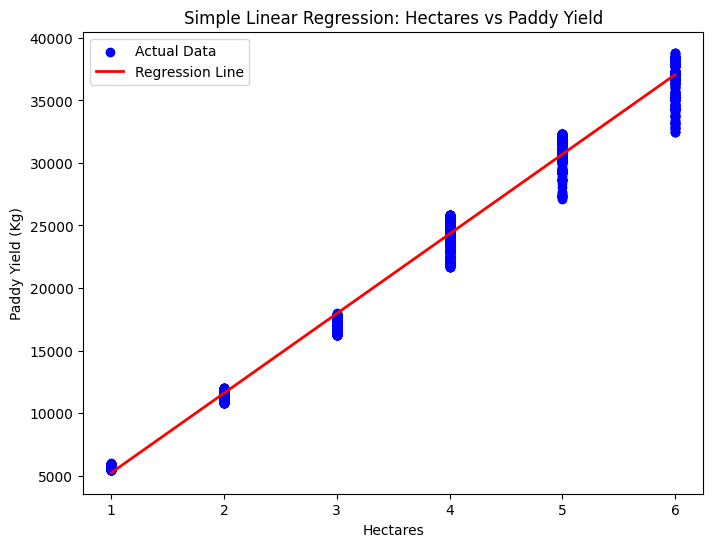

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create predictions for visualization
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)

plt.figure(figsize=(8,6))

# Plot actual data points
plt.scatter(X, y, color='blue', label='Actual Data')

# Plot regression line
plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Hectares")
plt.ylabel("Paddy Yield (Kg)")
plt.title("Simple Linear Regression: Hectares vs Paddy Yield")
plt.legend()

plt.show()

In [ ]:
slope = model.coef_[0]
print("slope(m):", slope)
intercept = model.intercept_
print("intercept(c):", intercept)

slope(m): 6365.027514874979
intercept(c): -1136.7510793704932


# EQUATION: Paddy Yield = 6365.0275 × Hectares + -1136.7511

if a farmer has 5 hectares,
The model predicts paddy yield = 30688.39 Kg

## Step 6: Make Predictions on Test Data

This is the real test of whether our model is good or bad
- Can it predict accurately on NEW data?


In [ ]:
y_predict = model.predict(X_test)
print("predicted values:",len(y_predict))


predicted values: 558


In [ ]:
# Print only y_test values (actual paddy yield) and corresponding hectares with their indexes
print(f"{'Index':<8} {'Hectares':<12} {'Paddy Yield (Kg)':<18}")
print('-'*40)
for idx, (hectares, yield_val) in enumerate(zip(X_test, y_test)):
    print(f"{idx:<8} {hectares[0]:<12.2f} {yield_val:<18.2f}")
print(f"\nTotal test samples: {len(y_test)}")

In [ ]:
# Print only y_test values (actual paddy yield) and corresponding hectares with their indexes
print(f"{'Index':<8} {'Hectares':<12} {'Paddy Yield (Kg)':<18}")
print('-'*40)
for idx, (hectares, yield_val) in enumerate(zip(X_test, y_test)):
    print(f"{idx:<8} {hectares[0]:<12.2f} {yield_val:<18.2f}")
print(f"\nTotal test samples: {len(y_test)}")

In [ ]:
y_pred = model.predict(X_test)

print("✓ Predictions Made on Test Data!")
print("\n" + "="*60)
print("📊 COMPARISON: Actual vs Predicted")
print("="*60)

# Display first 10 predictions vs actual values
print(f"\n{'Hectares':<12} {'Actual Yield':<18} {'Predicted Yield':<18} {'Error':<12}")
print("-" * 60)

for i in range(min(10, len(X_test))):
    actual = y_test[i]
    predicted = y_pred[i]
    error = actual - predicted
    hectares = X_test[i][0]
    print(f"{hectares:<12.2f} {actual:<18.2f} {predicted:<18.2f} {error:<12.2f}")

print(f"\n... (showing first 10 of {len(X_test)} test samples)\n")

✓ Predictions Made on Test Data!

📊 COMPARISON: Actual vs Predicted

Hectares     Actual Yield       Predicted Yield    Error       
------------------------------------------------------------
4.00         25640.00           24323.36           1316.64     
4.00         22512.00           24323.36           -1811.36    
4.00         25228.00           24323.36           904.64      
5.00         30575.00           30688.39           -113.39     
3.00         17649.00           17958.33           -309.33     
6.00         36690.00           37053.41           -363.41     
2.00         11256.00           11593.30           -337.30     
5.00         29415.00           30688.39           -1273.39    
4.00         23420.00           24323.36           -903.36     
3.00         16230.00           17958.33           -1728.33    

... (showing first 10 of 558 test samples)



## Step 7: Evaluate Model Performance using R² Score

**What is R² Score?**

R² (R-squared) tells us how good our model is. It answers: "How well does our line fit the data?"

**Explanation:**
- **R² = 1.0**: Perfect fit! All predictions are exactly correct
- **R² = 0.5**: Medium fit. Model explains 50% of variation
- **R² = 0.0**: Bad fit. Model is useless (as bad as just guessing average)
- **R² < 0**: Terrible fit. Worse than guessing!

**Mathematical Formula:**
$$R² = 1 - \frac{\text{Sum of Squared Errors}}{\text{Total Sum of Squares}}$$

**In simple terms:**
- Numerator: How wrong are the predictions?
- Denominator: How wrong would we be if we just guessed the average?
- If predictions are much better than average guess → R² is high (good!)
- If predictions are worse than average guess → R² is low (bad!)

In [ ]:
from sklearn.metrics import r2_score                  
from sklearn.metrics import mean_squared_error
# Calculate R² score
r2 = r2_score(y_test, y_pred)

# Also calculate Mean Squared Error (MSE) and Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("✓ Model Evaluation Complete!")
print("\n" + "="*60)
print("🎯 MODEL PERFORMANCE METRICS")
print("="*60)

print(f"\n📊 R² Score: {r2:.4f}")
if r2 >= 0.9:
    rating = "⭐⭐⭐⭐⭐ Excellent!"
elif r2 >= 0.7:
    rating = "⭐⭐⭐⭐ Very Good!"
elif r2 >= 0.5:
    rating = "⭐⭐⭐ Good"
elif r2 >= 0.3:
    rating = "⭐⭐ Fair"
else:
    rating = "⭐ Poor"
    
print(f"   Meaning: The model explains {r2*100:.2f}% of variance in the data")
print(f"   Rating: {rating}")

print(f"\n📉 Mean Squared Error (MSE): {mse:.4f}")
print(f"   (Average of squared prediction errors)")

print(f"\n📉 Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"   (How far off predictions are on average, in Kg)")
print(f"   Interpretation: On average, predictions are {rmse:.2f} Kg off")

# Training score too
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

print(f"\n" + "="*60)
print("📈 Training vs Testing Comparison:")
print("="*60)
print(f"   Training R²: {r2_train:.4f}")
print(f"   Testing R²:  {r2:.4f}")
print(f"\n   Difference: {abs(r2_train - r2):.4f}")
if abs(r2_train - r2) < 0.05:
    print("   ✓ Model is NOT overfitting (generalizes well!)")
else:
    print("   ⚠ Large difference suggests possible overfitting")

✓ Model Evaluation Complete!

🎯 MODEL PERFORMANCE METRICS

📊 R² Score: 0.9889
   Meaning: The model explains 98.89% of variance in the data
   Rating: ⭐⭐⭐⭐⭐ Excellent!

📉 Mean Squared Error (MSE): 900121.3850
   (Average of squared prediction errors)

📉 Root Mean Squared Error (RMSE): 948.7473
   (How far off predictions are on average, in Kg)
   Interpretation: On average, predictions are 948.75 Kg off

📈 Training vs Testing Comparison:
   Training R²: 0.9894
   Testing R²:  0.9889

   Difference: 0.0005
   ✓ Model is NOT overfitting (generalizes well!)


C:\Users\Avunoorihinduvahini\AppData\Local\Temp\ipykernel_10260\642797639.py:87: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Avunoorihinduvahini\AppData\Local\Temp\ipykernel_10260\642797639.py:87: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Avunoorihinduvahini\AppData\Local\Temp\ipykernel_10260\642797639.py:87: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Avunoorihinduvahini\AppData\Local\Temp\ipykernel_10260\642797639.py:87: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Avunoorihinduvahini\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users

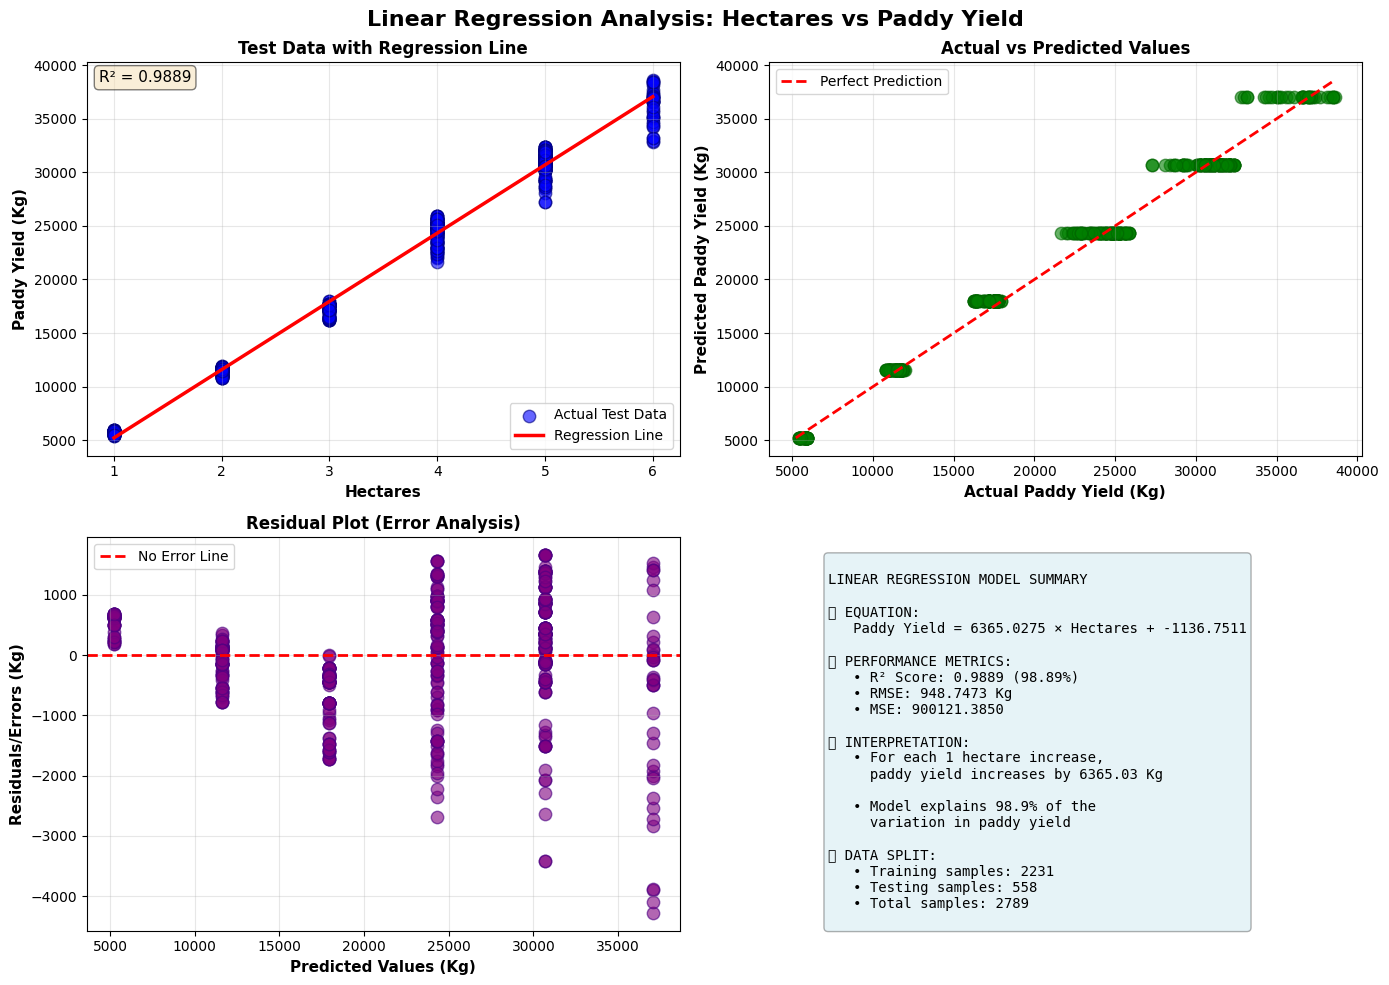


✓ Visualization Complete!


In [35]:
# Create a figure with multiple visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Regression Analysis: Hectares vs Paddy Yield', fontsize=16, fontweight='bold')

# ==================== PLOT 1: Regression Line with Test Data ====================
ax1 = axes[0, 0]

# Scatter plot of actual test data
ax1.scatter(X_test, y_test, color='blue', s=80, alpha=0.6, label='Actual Test Data', edgecolors='navy')

# Create line for regression
X_line = np.array([[X.min()], [X.max()]])  # Min and max values of X
y_line = model.predict(X_line)
ax1.plot(X_line, y_line, 'r-', linewidth=2.5, label='Regression Line')

ax1.set_xlabel('Hectares', fontsize=11, fontweight='bold')
ax1.set_ylabel('Paddy Yield (Kg)', fontsize=11, fontweight='bold')
ax1.set_title('Test Data with Regression Line', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.text(0.02, 0.98, f'R² = {r2:.4f}', transform=ax1.transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ==================== PLOT 2: Actual vs Predicted ====================
ax2 = axes[0, 1]

# Scatter: actual vs predicted
ax2.scatter(y_test, y_pred, color='green', s=80, alpha=0.6, edgecolors='darkgreen')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax2.set_xlabel('Actual Paddy Yield (Kg)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Predicted Paddy Yield (Kg)', fontsize=11, fontweight='bold')
ax2.set_title('Actual vs Predicted Values', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# ==================== PLOT 3: Residuals (Prediction Errors) ====================
ax3 = axes[1, 0]

residuals = y_test - y_pred
ax3.scatter(y_pred, residuals, color='purple', s=80, alpha=0.6, edgecolors='indigo')
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2, label='No Error Line')

ax3.set_xlabel('Predicted Values (Kg)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Residuals/Errors (Kg)', fontsize=11, fontweight='bold')
ax3.set_title('Residual Plot (Error Analysis)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# ==================== PLOT 4: Model Information ====================
ax4 = axes[1, 1]
ax4.axis('off')

# Create text information
info_text = f"""
LINEAR REGRESSION MODEL SUMMARY

📐 EQUATION:
   Paddy Yield = {slope:.4f} × Hectares + {intercept:.4f}

📊 PERFORMANCE METRICS:
   • R² Score: {r2:.4f} ({r2*100:.2f}%)
   • RMSE: {rmse:.4f} Kg
   • MSE: {mse:.4f}
   
📈 INTERPRETATION:
   • For each 1 hectare increase,
     paddy yield increases by {slope:.2f} Kg
   
   • Model explains {r2*100:.1f}% of the
     variation in paddy yield

📋 DATA SPLIT:
   • Training samples: {len(X_train)}
   • Testing samples: {len(X_test)}
   • Total samples: {len(X)}
"""

ax4.text(0.1, 0.95, info_text, transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n✓ Visualization Complete!")

In [36]:
# Make predictions on new, unseen data
new_hectares = np.array([[3.5], [7.5], [10.0], [15.0]])

predictions = model.predict(new_hectares)

print("🔮 PREDICTIONS FOR NEW DATA")
print("="*60)
print(f"\n{'Hectares':<12} {'Predicted Paddy Yield (Kg)':<30}")
print("-" * 60)

for hectares, yield_pred in zip(new_hectares, predictions):
    print(f"{hectares[0]:<12.2f} {yield_pred:<30.2f}")

print("\n" + "="*60)
print("💡 How to Interpret These Predictions:")
print("="*60)
print(f"""
If a farmer has:
  • 3.5 hectares  → Expected yield: {predictions[0]:.2f} Kg
  • 7.5 hectares  → Expected yield: {predictions[1]:.2f} Kg
  • 10.0 hectares → Expected yield: {predictions[2]:.2f} Kg
  • 15.0 hectares → Expected yield: {predictions[3]:.2f} Kg

⚠️  IMPORTANT NOTES:
1. These are ESTIMATES based on historical data
2. Real yield depends on weather, soil, fertilizer, etc.
3. Predictions are reliable only within the data range
   (Data range: {X.min():.2f} to {X.max():.2f} hectares)
4. Don't extrapolate too far beyond the data range!
""")

🔮 PREDICTIONS FOR NEW DATA

Hectares     Predicted Paddy Yield (Kg)    
------------------------------------------------------------
3.50         21140.85                      
7.50         46600.96                      
10.00        62513.52                      
15.00        94338.66                      

💡 How to Interpret These Predictions:

If a farmer has:
  • 3.5 hectares  → Expected yield: 21140.85 Kg
  • 7.5 hectares  → Expected yield: 46600.96 Kg
  • 10.0 hectares → Expected yield: 62513.52 Kg
  • 15.0 hectares → Expected yield: 94338.66 Kg

⚠️  IMPORTANT NOTES:
1. These are ESTIMATES based on historical data
2. Real yield depends on weather, soil, fertilizer, etc.
3. Predictions are reliable only within the data range
   (Data range: 1.00 to 6.00 hectares)
4. Don't extrapolate too far beyond the data range!

